# Bài tập: Biểu diễn dữ liệu tiếng nói

Tự cài đặt các bước từ waveform đến STFT/Spectrogram, sau đó dùng Librosa để sinh Mel-Spectrogram và MFCC. Trọng tâm là hiểu luồng dữ liệu và đọc được các biểu đồ.

```text
Waveform → Framing + Windowing → STFT tự cài đặt → Power Spectrogram → Librosa Mel-Spectrogram → Librosa MFCC
```

**Quy trình:** chạy lần lượt từng cell, quan sát shape và biểu đồ, hoàn thành các phần `TODO`, rồi kiểm chứng ở cuối bài.

## 1. Giới thiệu

- **Waveform** là biên độ của tín hiệu âm thanh theo thời gian.
- **FFT** cho biết tín hiệu chứa những thành phần tần số nào, nhưng không giữ thông tin chúng xuất hiện lúc nào.
- **STFT** giải quyết hạn chế đó bằng cách chia tín hiệu thành các đoạn ngắn rồi FFT từng đoạn.
- **Spectrogram, Mel-Spectrogram và MFCC** là các mức biểu diễn ngày càng gần cảm nhận thính giác và gọn hơn cho xử lý tiếng nói.

## 2. Chuẩn bị môi trường

In [11]:
# Nếu môi trường chưa có package, bỏ dấu # và chạy dòng sau một lần.
# %pip install numpy matplotlib scipy librosa soundfile

In [12]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import librosa
import librosa.display

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=3, suppress=True)

# Đặt file tiếng nói tại audio/speech.wav hoặc đổi đường dẫn này.
AUDIO_PATH = Path("audio/speech.wav")

## 3. Chuẩn bị dữ liệu tiếng nói

Trong bài tập này, bạn chỉ cần **một đoạn tiếng nói ngắn ở định dạng `.wav`**, không cần tải toàn bộ một speech dataset. Bạn có thể:

1. Tự ghi âm một câu nói bằng điện thoại hoặc máy tính rồi lưu/chuyển thành `.wav`.
2. Lấy một file `.wav` tiếng nói ngắn từ corpus công khai. Nếu muốn dùng tiếng Việt, bạn có thể lấy một utterance từ **VIVOS Vietnamese Speech Corpus**; với tiếng Anh, **LibriSpeech** là một lựa chọn phù hợp. Không cần tải hay xử lý toàn bộ dataset.
3. Sử dụng một file `.wav` tiếng nói khác mà bạn có sẵn.

**Khuyến nghị:** speech dài khoảng 2–10 giây, một người nói, ít nhiễu, không có nhạc nền. File gốc không bắt buộc phải là 16 kHz hoặc mono vì notebook sẽ chuẩn hóa khi đọc.

Hãy đặt file tại `audio/speech.wav`, hoặc thay đổi biến `AUDIO_PATH`. Khuyến khích dùng chính giọng nói của bạn, chẳng hạn: *"Xin chào, đây là bài tập xử lý tiếng nói."*

## 4. Quan sát Waveform và FFT

Tín hiệu minh họa dài 2 giây: 440 Hz ở giây đầu và 880 Hz ở giây sau. FFT toàn tín hiệu sẽ thấy cả hai tần số.

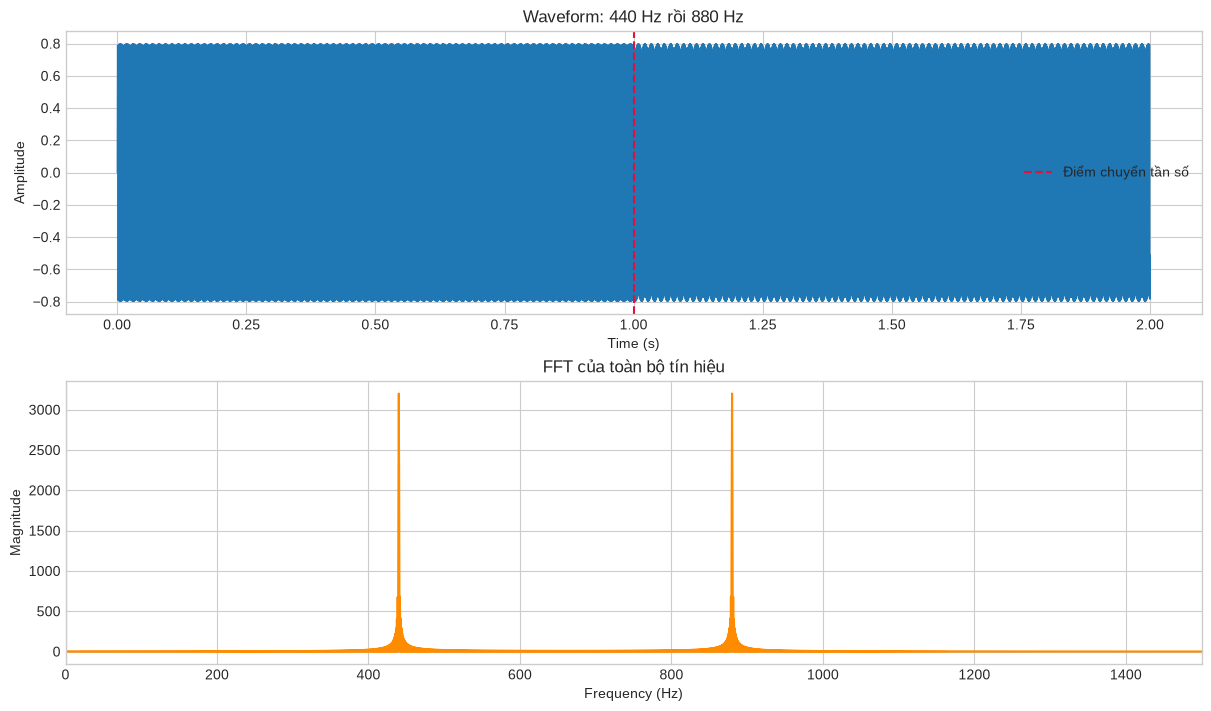

In [13]:
synthetic_sr = 8000
segment_duration = 1.0
samples_per_segment = int(synthetic_sr * segment_duration)
segment_time = np.arange(samples_per_segment) / synthetic_sr

first_tone = 0.8 * np.sin(2 * np.pi * 440 * segment_time)
second_tone = 0.8 * np.sin(2 * np.pi * 880 * segment_time)
synthetic_signal = np.concatenate([first_tone, second_tone])
synthetic_time = np.arange(len(synthetic_signal)) / synthetic_sr

fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True)
axes[0].plot(synthetic_time, synthetic_signal, linewidth=0.8)
axes[0].axvline(1.0, color="crimson", linestyle="--", label="Điểm chuyển tần số")
axes[0].set(title="Waveform: 440 Hz rồi 880 Hz", xlabel="Time (s)", ylabel="Amplitude")
axes[0].legend()

full_fft = np.fft.rfft(synthetic_signal)
fft_frequencies = np.fft.rfftfreq(len(synthetic_signal), d=1 / synthetic_sr)
axes[1].plot(fft_frequencies, np.abs(full_fft), color="darkorange")
axes[1].set(xlim=(0, 1500), title="FFT của toàn bộ tín hiệu", xlabel="Frequency (Hz)", ylabel="Magnitude")
plt.show()

## 5. Framing: chia tín hiệu thành các đoạn ngắn

`frame_length` là số sample trong một frame; `hop_length` là số sample dịch sang phải giữa hai frame liên tiếp. Khi `hop_length < frame_length`, các frame chồng lấp nhau. Hàm dưới đây chỉ lấy các frame đầy đủ để shape luôn rõ ràng.

In [14]:
# ============================================================
# TODO 1: Tự cài đặt quá trình chia tín hiệu thành các frame chồng lấp nhau.
# Gợi ý: Tính vị trí bắt đầu của từng frame bằng hop_length.
# ============================================================

# ----- SOLUTION -----
def framing(signal, frame_length, hop_length):
    num_frames = 1 + int((len(signal) - frame_length) / hop_length)
    frames = np.empty((num_frames, frame_length), dtype=signal.dtype)
    for i in range(num_frames):
        start = i * hop_length
        frames[i] = signal[start : start + frame_length]
    return frames

Frames shape: (198, 200)


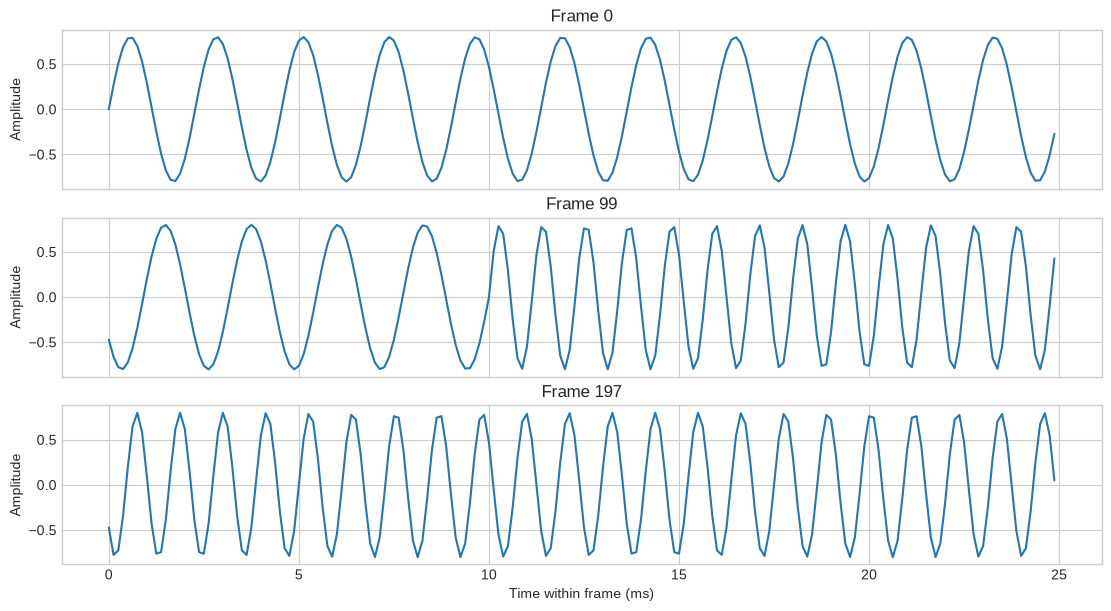

In [15]:
demo_frame_length = int(0.025 * synthetic_sr)  # 25 ms
demo_hop_length = int(0.010 * synthetic_sr)    # 10 ms
demo_frames = framing(synthetic_signal, demo_frame_length, demo_hop_length)
print("Frames shape:", demo_frames.shape)

fig, axes = plt.subplots(3, 1, figsize=(11, 6), sharex=True, constrained_layout=True)
for axis, frame_index in zip(axes, [0, len(demo_frames) // 2, len(demo_frames) - 1]):
    local_time_ms = np.arange(demo_frame_length) / synthetic_sr * 1000
    axis.plot(local_time_ms, demo_frames[frame_index])
    axis.set_ylabel("Amplitude")
    axis.set_title(f"Frame {frame_index}")
axes[-1].set_xlabel("Time within frame (ms)")
plt.show()

## 6. Windowing và STFT

Cắt đột ngột ở biên frame gây rò rỉ phổ. Cửa sổ Hann làm biên frame giảm dần về gần 0. Mỗi `rFFT` tạo phổ cho một frame; vì input là tín hiệu thực, `rfft` chỉ cần giữ các tần số không âm.

In [16]:
# ============================================================
# TODO 2: Tự cài đặt STFT bằng framing, cửa sổ Hann và rFFT.
# Gợi ý: Window từng frame, zero-pad đến n_fft, rồi chuyển vị kết quả.
# ============================================================

# ----- SOLUTION -----
def my_stft(signal, n_fft, hop_length, win_length):
    frames = framing(signal, win_length, hop_length)
    window = np.hanning(win_length)
    windowed_frames = frames * window
    # Zero-pad lên n_fft nếu n_fft > win_length, sau đó tính rFFT dọc theo từng frame (axis=-1)
    stft_matrix = np.fft.rfft(windowed_frames, n=n_fft, axis=-1)
    # Chuyển vị để trả về shape (n_fft // 2 + 1, num_frames) khớp với librosa.stft
    return stft_matrix.T


n_fft_demo = 256
stft_demo = my_stft(synthetic_signal, n_fft_demo, demo_hop_length, demo_frame_length)
print("STFT shape:", stft_demo.shape)
print("Expected frequency bins:", n_fft_demo // 2 + 1)

STFT shape: (129, 198)
Expected frequency bins: 129


## 7. Magnitude, Power và Decibel

Với hệ số STFT phức $X(m,k)$:

$$
\text{Magnitude}(m,k)=|X(m,k)|, \qquad P(m,k)=|X(m,k)|^2
$$

Thang dB nén dynamic range. Một epsilon nhỏ giúp tránh $\log(0)$.

In [17]:
# ============================================================
# TODO 3: Tính Magnitude Spectrogram và Power Spectrogram từ STFT.
# Gợi ý: Dùng trị tuyệt đối của số phức; power là bình phương magnitude.
# ============================================================

# ----- SOLUTION -----
def magnitude_spectrogram(stft_matrix):

    # VIẾT CODE TẠI ĐÂY

    return np.abs(stft_matrix)

def power_spectrogram(stft_matrix):
    
    # VIẾT CODE TẠI ĐÂY

    return np.abs(stft_matrix) ** 2

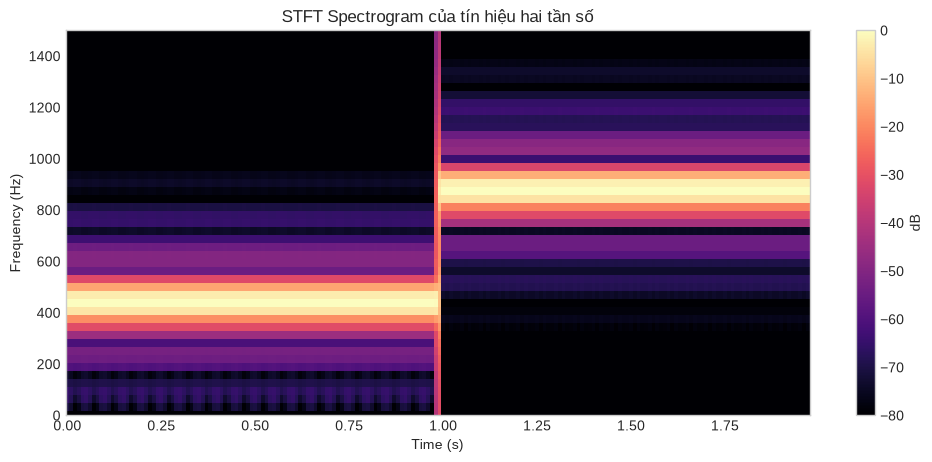

In [18]:
# ============================================================
# TODO 4: Chuyển Power Spectrogram sang dB và giới hạn dynamic range.
# Gợi ý: Chuẩn hóa theo power lớn nhất, thêm epsilon trước log10.
# ============================================================

# ----- SOLUTION -----
def power_to_db(power_spec, top_db=80.0):

    # VIẾT CODE TẠI ĐÂY
    
    ref_value = np.max(power_spec)
    # Thêm epsilon để tránh chia hoặc log số 0
    eps = 1e-10
    power_db = 10.0 * np.log10(np.maximum(power_spec, eps) / np.maximum(ref_value, eps))
    # Giới hạn dynamic range trong khoảng [max - top_db, max]
    power_db = np.maximum(power_db, power_db.max() - top_db)
    return power_db


power_demo = power_spectrogram(stft_demo)
db_demo = power_to_db(power_demo)
demo_times = np.arange(db_demo.shape[1]) * demo_hop_length / synthetic_sr
demo_frequencies = np.fft.rfftfreq(n_fft_demo, d=1 / synthetic_sr)

plt.figure(figsize=(12, 5))
plt.pcolormesh(demo_times, demo_frequencies, db_demo, shading="auto", cmap="magma")
plt.ylim(0, 1500)
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("STFT Spectrogram của tín hiệu hai tần số")
plt.colorbar(label="dB")
plt.show()

assert np.isfinite(db_demo).all()

## 8. Thí nghiệm Time–Frequency Resolution

Chạy cùng tín hiệu với cửa sổ 10 ms, 25 ms và 50 ms. Để phép so sánh rõ ràng, hop bằng 1/4 độ dài cửa sổ và `n_fft` là lũy thừa 2 gần nhất không nhỏ hơn `win_length`.

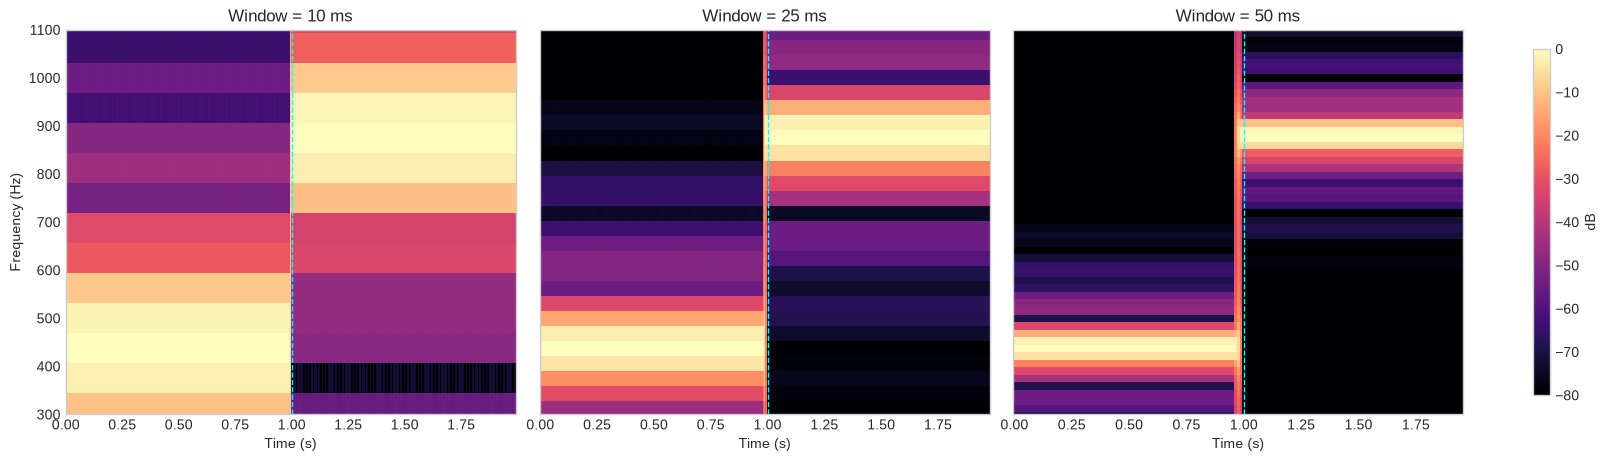

In [19]:
window_sizes_ms = [10, 25, 50]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True, constrained_layout=True)

for axis, window_ms in zip(axes, window_sizes_ms):
    win_length = round(window_ms / 1000 * synthetic_sr)
    hop_length = max(1, win_length // 4)
    n_fft = 1 << int(np.ceil(np.log2(win_length)))
    current_stft = my_stft(synthetic_signal, n_fft, hop_length, win_length)
    current_db = power_to_db(power_spectrogram(current_stft))
    times = np.arange(current_db.shape[1]) * hop_length / synthetic_sr
    frequencies = np.fft.rfftfreq(n_fft, d=1 / synthetic_sr)
    image = axis.pcolormesh(times, frequencies, current_db, shading="auto", cmap="magma")
    axis.axvline(1.0, color="cyan", linestyle="--", linewidth=1)
    axis.set(title=f"Window = {window_ms} ms", xlabel="Time (s)", ylim=(300, 1100))
axes[0].set_ylabel("Frequency (Hz)")
fig.colorbar(image, ax=axes, label="dB", shrink=0.9)
plt.show()

## 9. Đọc và quan sát tín hiệu tiếng nói

Audio: audio/speech.wav
Sample rate: 16000 Hz
Number of samples: 61440
Duration: 3.84 s


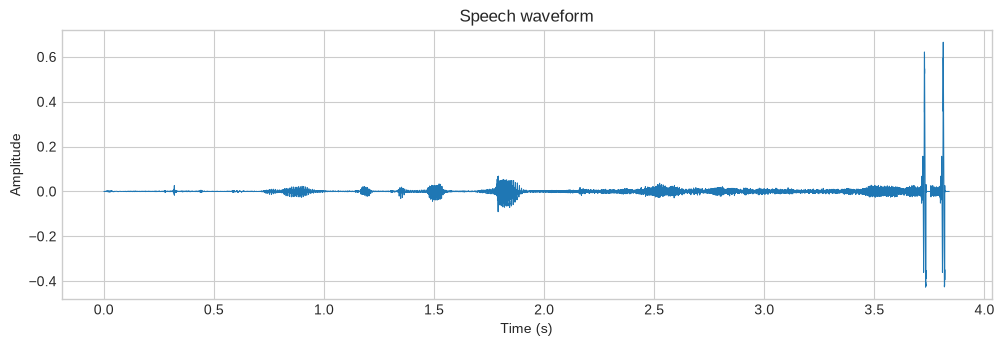

In [20]:
if not AUDIO_PATH.exists():
    raise FileNotFoundError(
        f"Không tìm thấy file: {AUDIO_PATH}\n\n"
        "Hãy:\n"
        "1. tạo thư mục audio nếu chưa có;\n"
        "2. đặt một file tiếng nói .wav vào đó;\n"
        "3. đổi tên file thành speech.wav;\n\n"
        "hoặc thay đổi biến AUDIO_PATH."
    )

# Phần giải mã WAV, chuyển mono và resampling được cung cấp sẵn.
speech_signal, speech_sr = librosa.load(AUDIO_PATH, sr=16000, mono=True)
speech_signal = speech_signal.astype(np.float64)
speech_duration = len(speech_signal) / speech_sr

print("Audio:", AUDIO_PATH)
print("Sample rate:", speech_sr, "Hz")
print("Number of samples:", len(speech_signal))
print(f"Duration: {speech_duration:.2f} s")
if speech_duration > 15:
    print("Lưu ý: Audio khá dài. Nên sử dụng đoạn speech khoảng 2–10 giây để biểu đồ dễ quan sát.")

speech_time = np.arange(len(speech_signal)) / speech_sr
plt.figure(figsize=(12, 3.5))
plt.plot(speech_time, speech_signal, linewidth=0.7)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Speech waveform")
plt.show()
display(Audio(speech_signal, rate=speech_sr))

## 10. Sinh Mel-Spectrogram bằng Librosa

Từ phần này, ta dùng thư viện thay vì tự cài đặt thang Mel và Mel Filterbank. Mel-Spectrogram gom năng lượng phổ theo các dải tần phù hợp hơn với cảm nhận thính giác.

In [21]:
# ============================================================
# TODO 5: Sinh Mel-Spectrogram từ Power Spectrogram bằng Librosa.
# Gợi ý: Dùng librosa.feature.melspectrogram với tham số S=speech_power.
# ============================================================

# ----- SOLUTION -----
speech_win_length = round(0.025 * speech_sr)
speech_hop_length = round(0.010 * speech_sr)
speech_n_fft = 1 << int(np.ceil(np.log2(speech_win_length)))
n_mels = 40

speech_stft = my_stft(speech_signal, speech_n_fft, speech_hop_length, speech_win_length)
speech_power = power_spectrogram(speech_stft)

# VIẾT CODE TẠI ĐÂY


mel_spectrogram = librosa.feature.melspectrogram(
    S=speech_power,
    sr=speech_sr,
    n_fft=speech_n_fft,
    hop_length=speech_hop_length,
    n_mels=n_mels,
    power=2.0
)

Mel-Spectrogram shape: (40, 382)


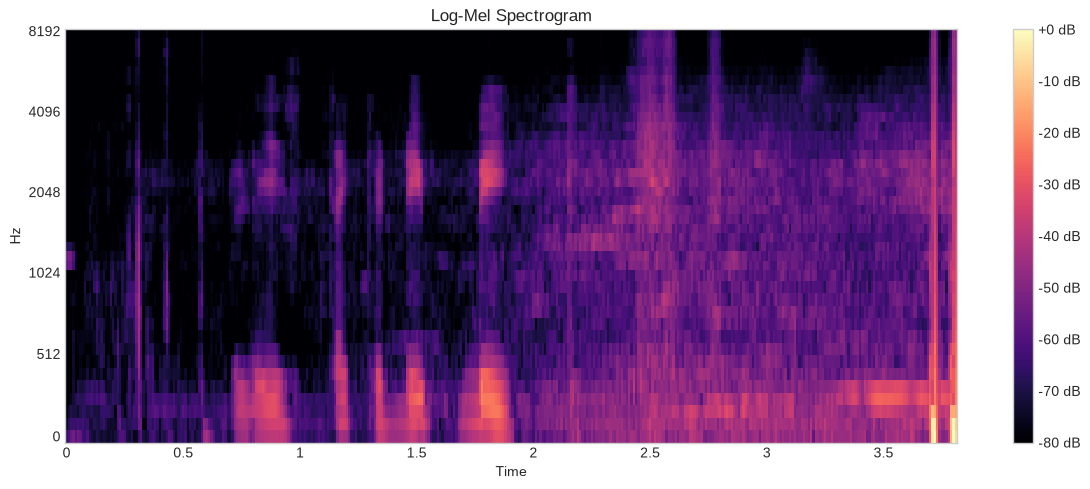

In [22]:
log_mel = librosa.power_to_db(mel_spectrogram, ref=np.max)
print("Mel-Spectrogram shape:", mel_spectrogram.shape)

plt.figure(figsize=(12, 5))
librosa.display.specshow(
    log_mel, sr=speech_sr, hop_length=speech_hop_length,
    x_axis="time", y_axis="mel", cmap="magma"
)
plt.title("Log-Mel Spectrogram")
plt.colorbar(format="%+2.0f dB")
plt.tight_layout()
plt.show()

## 11. Sinh MFCC bằng Librosa

MFCC là biểu diễn gọn được suy ra từ Log-Mel Spectrogram. Trong bài này, Librosa thực hiện phép biến đổi; nhiệm vụ chính là sinh đặc trưng và đọc heatmap.

In [26]:
# ============================================================
# TODO 6: Sinh 13 hệ số MFCC từ Log-Mel Spectrogram bằng Librosa.
# Gợi ý: Dùng librosa.feature.mfcc với S=log_mel và n_mfcc=13.
# ============================================================

# ----- SOLUTION -----

mfcc = librosa.feature.mfcc(
    S=log_mel,
    sr=speech_sr,
    n_mfcc=13
)




MFCC shape: (13, 382)


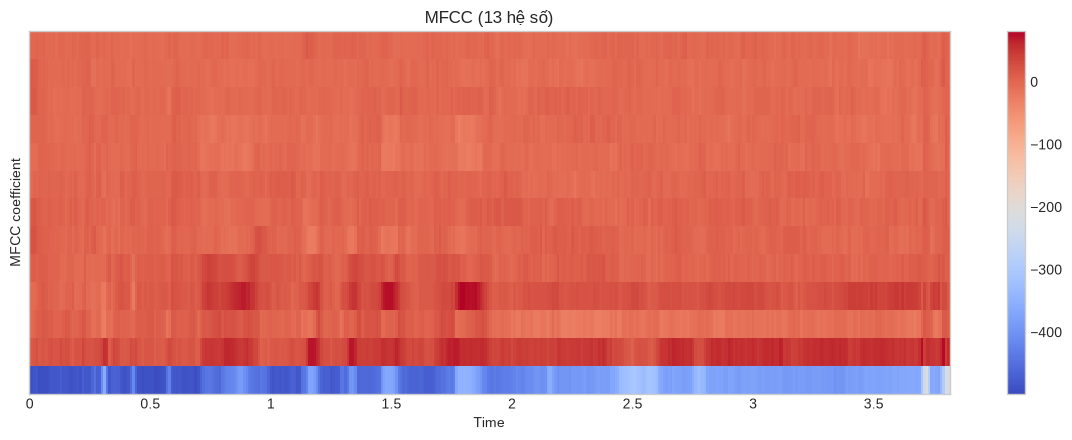

In [27]:
print("MFCC shape:", mfcc.shape)
plt.figure(figsize=(12, 4.5))
librosa.display.specshow(
    mfcc, sr=speech_sr, hop_length=speech_hop_length,
    x_axis="time", cmap="coolwarm"
)
plt.ylabel("MFCC coefficient")
plt.title("MFCC (13 hệ số)")
plt.colorbar()
plt.tight_layout()
plt.show()

## 12. Kiểm tra và trực quan hóa kết quả

Kiểm tra shape và đặt hai biểu diễn cạnh nhau để dễ quan sát cấu trúc theo thời gian.

In [28]:
print("Power Spectrogram:", speech_power.shape)
print("Mel-Spectrogram:  ", mel_spectrogram.shape)
print("Log-Mel:          ", log_mel.shape)
print("MFCC:             ", mfcc.shape)

Power Spectrogram: (257, 382)
Mel-Spectrogram:   (40, 382)
Log-Mel:           (40, 382)
MFCC:              (13, 382)


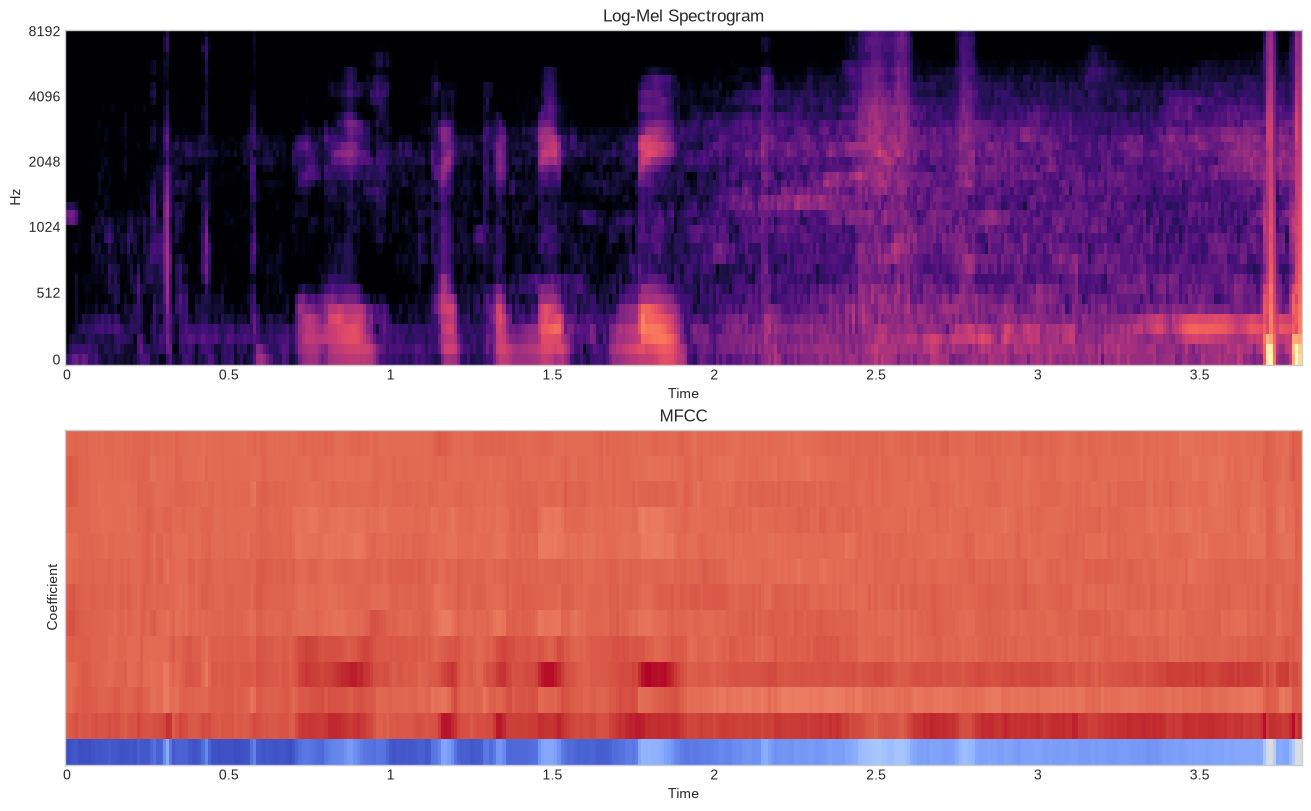

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(13, 8), constrained_layout=True)
librosa.display.specshow(log_mel, sr=speech_sr, hop_length=speech_hop_length,
                         x_axis="time", y_axis="mel", cmap="magma", ax=axes[0])
axes[0].set_title("Log-Mel Spectrogram")
librosa.display.specshow(mfcc, sr=speech_sr, hop_length=speech_hop_length,
                         x_axis="time", cmap="coolwarm", ax=axes[1])
axes[1].set(title="MFCC", ylabel="Coefficient")
plt.show()

Mel-Spectrogram thể hiện năng lượng trên thang tần số cảm nhận; MFCC cô đọng thông tin phổ vào ít hệ số hơn. Không cần tự cài đặt các phép biến đổi này trong bài tập.

In [30]:
feature_summary = {
    "waveform": speech_signal.shape,
    "power_spectrogram": speech_power.shape,
    "mel_spectrogram": mel_spectrogram.shape,
    "mfcc": mfcc.shape,
}
feature_summary

{'waveform': (61440,),
 'power_spectrogram': (257, 382),
 'mel_spectrogram': (40, 382),
 'mfcc': (13, 382)}

## 13. So sánh toàn bộ biểu diễn

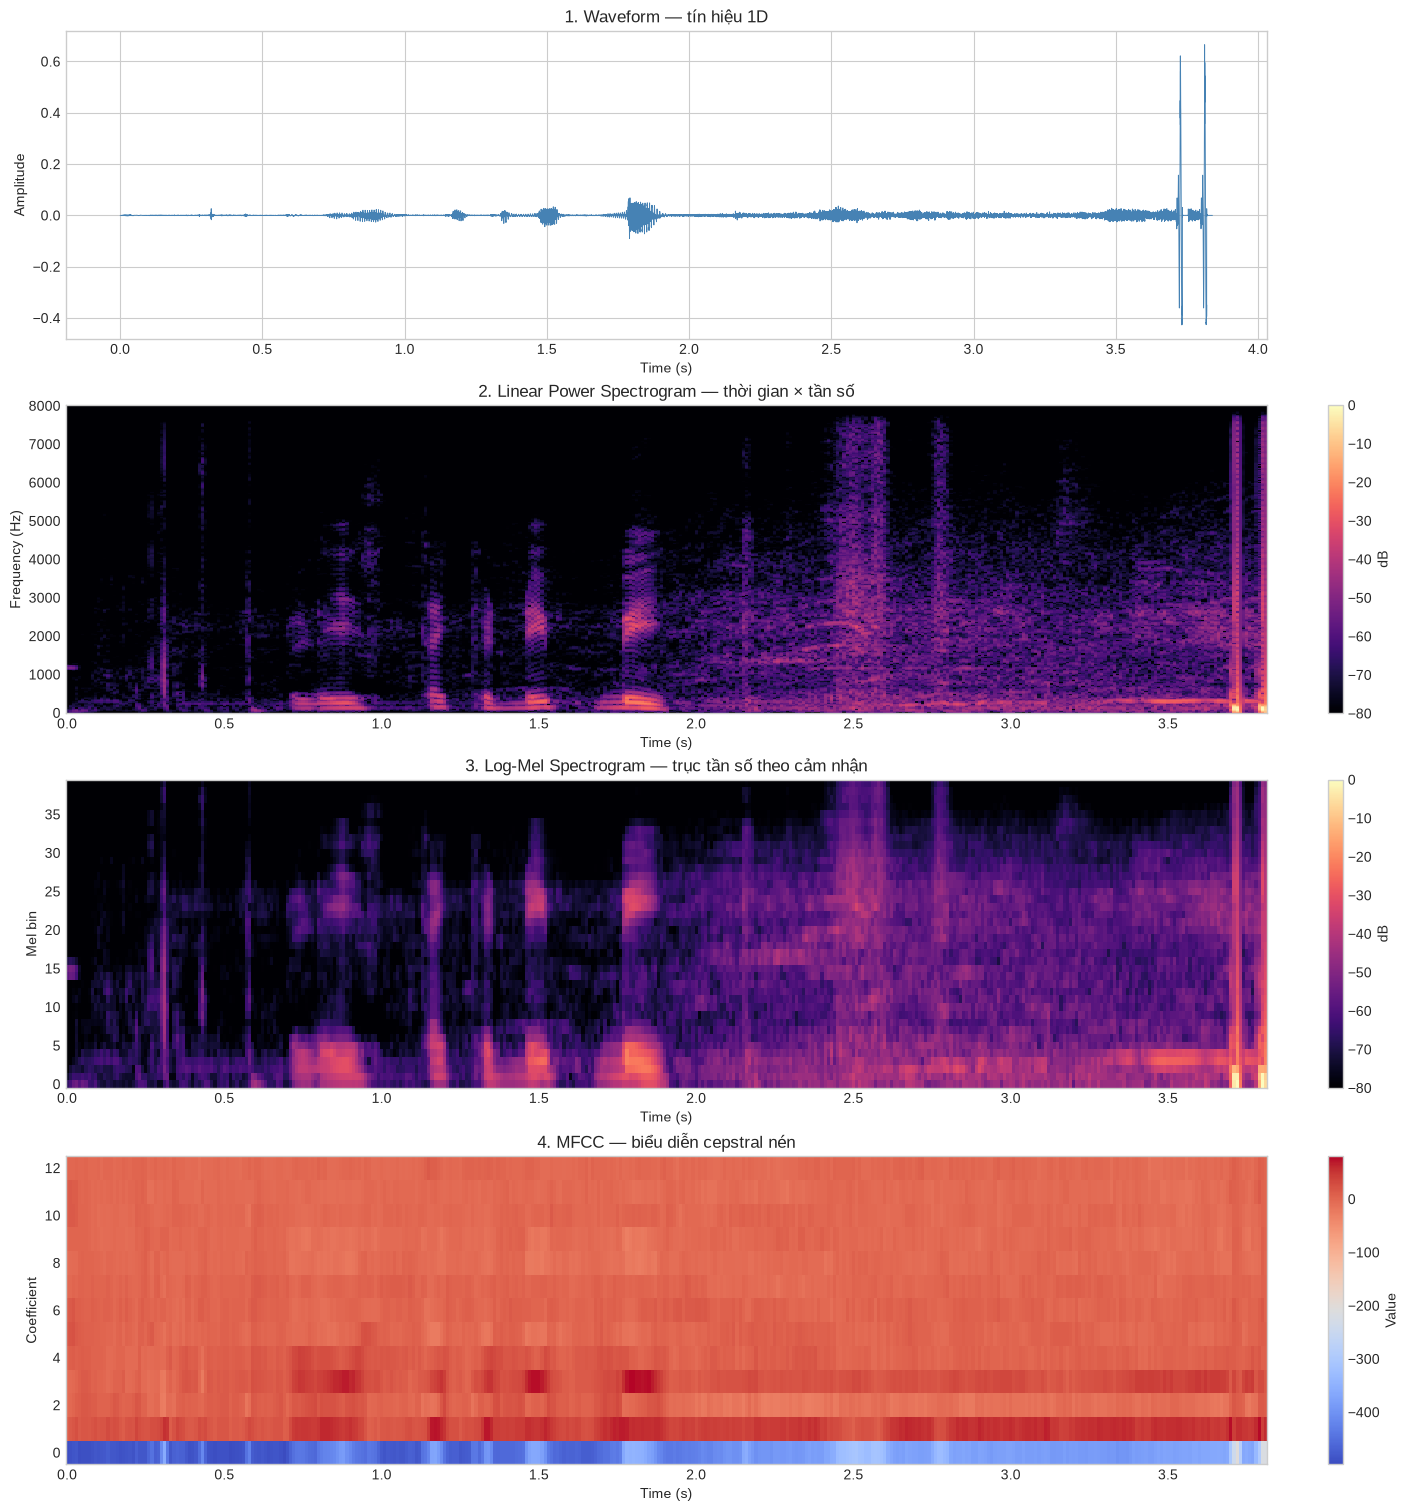

In [31]:
speech_db = power_to_db(speech_power)
speech_frequencies = np.fft.rfftfreq(speech_n_fft, d=1 / speech_sr)
speech_frame_times = np.arange(speech_power.shape[1]) * speech_hop_length / speech_sr

fig, axes = plt.subplots(4, 1, figsize=(14, 15), constrained_layout=True)
axes[0].plot(speech_time, speech_signal, color="steelblue", linewidth=0.65)
axes[0].set(title="1. Waveform — tín hiệu 1D", xlabel="Time (s)", ylabel="Amplitude")

linear_image = axes[1].pcolormesh(speech_frame_times, speech_frequencies, speech_db,
                                  shading="auto", cmap="magma")
axes[1].set(title="2. Linear Power Spectrogram — thời gian × tần số", xlabel="Time (s)", ylabel="Frequency (Hz)")
fig.colorbar(linear_image, ax=axes[1], label="dB")

mel_image = axes[2].pcolormesh(speech_frame_times, np.arange(n_mels), log_mel,
                               shading="auto", cmap="magma")
axes[2].set(title="3. Log-Mel Spectrogram — trục tần số theo cảm nhận", xlabel="Time (s)", ylabel="Mel bin")
fig.colorbar(mel_image, ax=axes[2], label="dB")

mfcc_image = axes[3].pcolormesh(speech_frame_times, np.arange(mfcc.shape[0]), mfcc,
                                shading="auto", cmap="coolwarm")
axes[3].set(title="4. MFCC — biểu diễn cepstral nén", xlabel="Time (s)", ylabel="Coefficient")
fig.colorbar(mfcc_image, ax=axes[3], label="Value")
plt.show()

## 14. Đối chiếu STFT tự cài đặt với Librosa

Chỉ STFT là phần cần đối chiếu với thư viện. Mel-Spectrogram và MFCC ở các phần trên đã được sinh trực tiếp bằng Librosa.

STFT tự cài đặt: (257, 382)
STFT từ Librosa:  (257, 381)


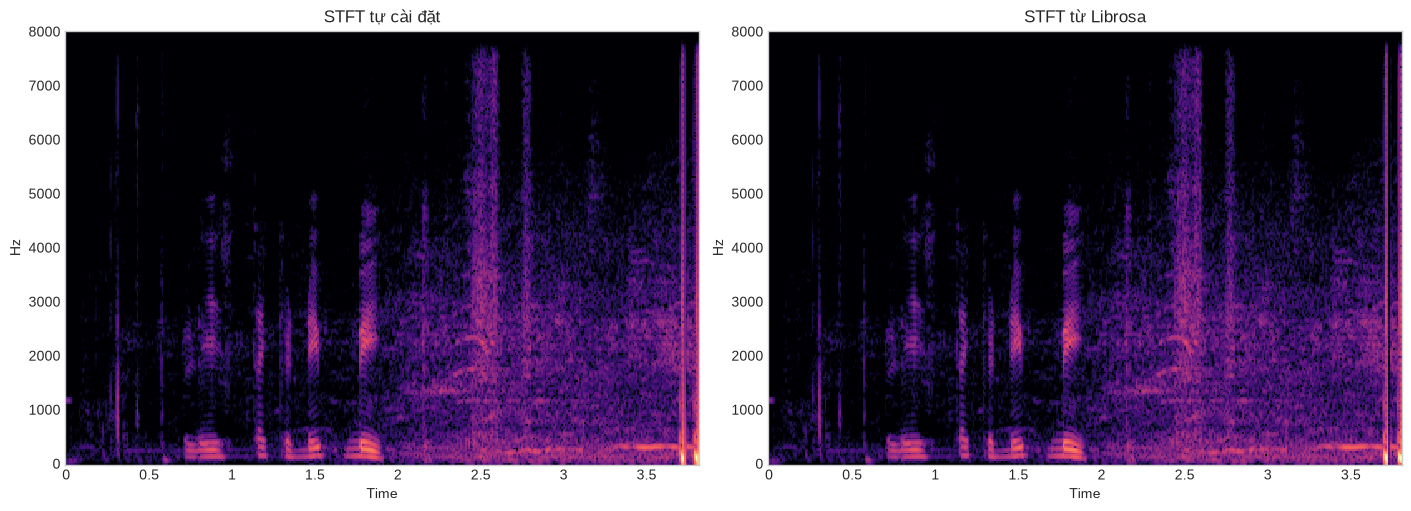

In [32]:
librosa_stft = librosa.stft(
    speech_signal,
    n_fft=speech_n_fft,
    hop_length=speech_hop_length,
    win_length=speech_win_length,
    window="hann",
    center=False,
)
print("STFT tự cài đặt:", speech_stft.shape)
print("STFT từ Librosa: ", librosa_stft.shape)

manual_stft_db = power_to_db(np.abs(speech_stft) ** 2)
librosa_stft_db = librosa.amplitude_to_db(np.abs(librosa_stft), ref=np.max)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
librosa.display.specshow(manual_stft_db, sr=speech_sr, hop_length=speech_hop_length,
                         x_axis="time", y_axis="linear", cmap="magma", ax=axes[0])
axes[0].set_title("STFT tự cài đặt")
librosa.display.specshow(librosa_stft_db, sr=speech_sr, hop_length=speech_hop_length,
                         x_axis="time", y_axis="linear", cmap="magma", ax=axes[1])
axes[1].set_title("STFT từ Librosa")
plt.show()